In [1]:
import os
import cv2
import numpy as np
import mediapipe as mp
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import load_model


In [2]:
import torch
torch.cuda.is_available()

True

In [3]:
data_dirs = {
    "train": "../affectnet_dataset/Train",
    "test": "../affectnet_dataset/Test"
}
# data_dirs = {
#     "train": "./rgb_dataset/train",
#     "test": "./rgb_dataset/test",
#     "val": "./rgb_dataset/val"
# }
keypoints_dir = "../keypoints_dataset"

os.makedirs(keypoints_dir, exist_ok=True)

In [4]:
EPOCHS = 50
RANDOM_SEED = 40
BATCH_SIZE = 32
EMOTIONS = ['Anger', 'Contempt', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [5]:
mp_holistic = mp.solutions.holistic # Holistic model 
mp_drawing = mp.solutions.drawing_utils # Drawing utilities 
mp_face_mesh = mp.solutions.face_mesh

In [6]:
def mediapipe_detection(image, model): 
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.setflags(write=False)         # Image is no longer writable
    results = model.process(image)      # Make prediction
    image.setflags(write=True)          # Image is now writable
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results


In [7]:
def draw_styled_landmarks(image, results):

    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_face_mesh.FACEMESH_CONTOURS,
                              mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),  
                              mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                              )
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [8]:
# def extract_keypoints(results):
#     if results.face_landmarks:
#         return np.array(
#             [[lm.x, lm.y, lm.z] for lm in results.face_landmarks.landmark]
#         ).flatten()
#     else:
#         return np.zeros(468*3)

In [9]:
# #same logic as above but in function, so can be used
# def extract_keypoints(results):
#     pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
#     face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
#     lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
#     rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
#     return np.concatenate([pose, face, lh, rh]) # flatten arr of points x,y,z visibility values - single vector

def extract_keypoints(results):
    if results.face_landmarks:
        face = np.array(
            [[lm.x, lm.y, lm.z] for lm in results.face_landmarks.landmark]
        )

        # center
        center = face.mean(axis=0)
        face = face - center

        # scale normalize
        scale = np.linalg.norm(face.max(axis=0) - face.min(axis=0))
        if scale != 0:
            face = face / scale

        return face.flatten()
    else:
        return np.zeros(468 * 3)

In [10]:
# # Extract keypoints and save as .npy files
# with mp_holistic.Holistic(static_image_mode=True) as holistic:
#     for split, split_dir in data_dirs.items():
#         for class_name in sorted(os.listdir(split_dir)):
#             class_path = os.path.join(split_dir, class_name)
#             if not os.path.isdir(class_path):
#                 continue
            
#             # Make parallel folder in keypoints_dir
#             save_class_path = os.path.join(keypoints_dir, split, class_name)
#             os.makedirs(save_class_path, exist_ok=True)
            
#             for img_name in os.listdir(class_path):
#                 if img_name.startswith("."):  # skip hidden files
#                     continue
#                 img_path = os.path.join(class_path, img_name)
                
#                 # Read, convert, resize
#                 img = cv2.imread(img_path)
#                 if img is None:
#                     continue
#                 img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#                 img = cv2.resize(img, (75, 75))
                
#                 # Extract keypoints
#                 results = holistic.process(img)
#                 keypoints = extract_keypoints(results)
                
#                 # Save keypoints as .npy
#                 save_path = os.path.join(save_class_path, img_name.split('.')[0] + ".npy")
#                 np.save(save_path, keypoints)

# print("Keypoints saved in folder:", keypoints_dir)

In [11]:
folder = "../keypoints_dataset/Train/Contempt"

# List all .npy files
files = [f for f in os.listdir(folder) if f.endswith(".npy")]

first_img = os.path.join(folder, files[0])
keypoints = np.load(first_img)
print(keypoints.shape)

(1404,)


In [12]:
# Load keypoints arrays
def load_keypoints_dataset(base_dir):
    X, y = [], []
    for class_name in sorted(os.listdir(base_dir)):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file in os.listdir(class_path):
            if not file.endswith(".npy"):
                continue
            keypoints = np.load(os.path.join(class_path, file))
            X.append(keypoints)
            y.append(class_name)
    return np.array(X), np.array(y)

X, y = load_keypoints_dataset("../keypoints_dataset/train")

le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y)

# Split FIRST
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# THEN standardize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
print(X_train.shape, y_train.shape)

(12886, 1404) (12886, 8)


In [13]:
num_classes = y_train.shape[1]

model = Sequential([
    # X_train.shape[1] is number of features, X_train.shape[0] is number of samples
    Dense(1024, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

optimizer = Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\User\anaconda3\envs\cuda\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1024)                │       1,438,720 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │           2,056 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,096,904 (8.00 MB)

 Trainable params: 2,096,904 (8.00 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
mc = ModelCheckpoint('../saved_models/rgb_mp.h5', monitor='val_accuracy', save_best_only=True)
csv_logger = CSVLogger('training_log.csv')

In [15]:
# # Calculate class weights (class imbalance handling)

# y_labels = np.argmax(y_train, axis=1)

# class_weights_array = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(y_labels),
#     y=y_labels
# )

# class_weights = dict(enumerate(class_weights_array))
# print("Class weights:", class_weights)

In [16]:
import time
start = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    # class_weight=class_weights,
    callbacks=[es, mc, csv_logger]
)
end = time.time()

print("Training time: ", (end - start)/60)

Epoch 1/50
397/403 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2515 - loss: 2.5258

403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2908 - loss: 2.1670 - val_accuracy: 0.3957 - val_loss: 1.6959
Epoch 2/50
400/403 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3681 - loss: 1.7648

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3668 - loss: 1.7477 - val_accuracy: 0.4131 - val_loss: 1.6435
Epoch 3/50
398/403 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3804 - loss: 1.6860

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3812 - loss: 1.6866 - val_accuracy: 0.4413 - val_loss: 1.5592
Epoch 4/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3950 - loss: 1.6637 - val_accuracy: 0.4327 - val_loss: 1.5357
Epoch 5/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4035 - loss: 1.6434 - val_accuracy: 0.4348 - val_loss: 1.5659
Epoch 6/50
400/403 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4039 - loss: 1.6344

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4075 - loss: 1.6278 - val_accuracy: 0.4510 - val_loss: 1.5120
Epoch 7/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4097 - loss: 1.6250 - val_accuracy: 0.4109 - val_loss: 1.5291
Epoch 8/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4157 - loss: 1.6156 - val_accuracy: 0.4460 - val_loss: 1.5166
Epoch 9/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4163 - loss: 1.6079

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4183 - loss: 1.6084 - val_accuracy: 0.4550 - val_loss: 1.5224
Epoch 10/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4231 - loss: 1.6119 - val_accuracy: 0.4534 - val_loss: 1.4834
Epoch 11/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4212 - loss: 1.5927 - val_accuracy: 0.4460 - val_loss: 1.4962
Epoch 12/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4180 - loss: 1.5961 - val_accuracy: 0.4404 - val_loss: 1.5034
Epoch 13/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4209 - loss: 1.5957 - val_accuracy: 0.4525 - val_loss: 1.4889
Epoch 14/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4209 - loss: 1.5956 - val_accuracy: 0.4426 - val_loss: 1.5107
Epoch 15/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4256 - loss: 1.5945 - val_accuracy: 0.4531 - val_loss: 1.4738
Epoch 16/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4324 - loss: 1.5797 - val_accuracy: 0.4317

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4285 - loss: 1.5879 - val_accuracy: 0.4590 - val_loss: 1.4891
Epoch 19/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4343 - loss: 1.5740 - val_accuracy: 0.4578 - val_loss: 1.4745
Epoch 20/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4320 - loss: 1.5793 - val_accuracy: 0.4547 - val_loss: 1.4567
Epoch 21/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4342 - loss: 1.5685 - val_accuracy: 0.4469 - val_loss: 1.4746
Epoch 22/50
402/403 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4356 - loss: 1.5615

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4328 - loss: 1.5703 - val_accuracy: 0.4615 - val_loss: 1.4800
Epoch 23/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4243 - loss: 1.5652

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4308 - loss: 1.5652 - val_accuracy: 0.4655 - val_loss: 1.4437
Epoch 24/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4385 - loss: 1.5692 - val_accuracy: 0.4640 - val_loss: 1.4556
Epoch 25/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4350 - loss: 1.5732 - val_accuracy: 0.4525 - val_loss: 1.4666
Epoch 26/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4360 - loss: 1.5738 - val_accuracy: 0.4584 - val_loss: 1.4516
Epoch 27/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4374 - loss: 1.5683 - val_accuracy: 0.4519 - val_loss: 1.4761
Epoch 28/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4325 - loss: 1.5682 - val_accuracy: 0.4590 - val_loss: 1.4587
Epoch 29/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4406 - loss: 1.5757 - val_accuracy: 0.4581 - val_loss: 1.4758
Epoch 30/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4373 - loss: 1.5527 - val_accuracy: 0.4482

403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4378 - loss: 1.5660 - val_accuracy: 0.4677 - val_loss: 1.4498
Epoch 32/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4384 - loss: 1.5565 - val_accuracy: 0.4593 - val_loss: 1.4446
Epoch 33/50
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4332 - loss: 1.5719 - val_accuracy: 0.4575 - val_loss: 1.4585
Training time:  1.8190043250719705


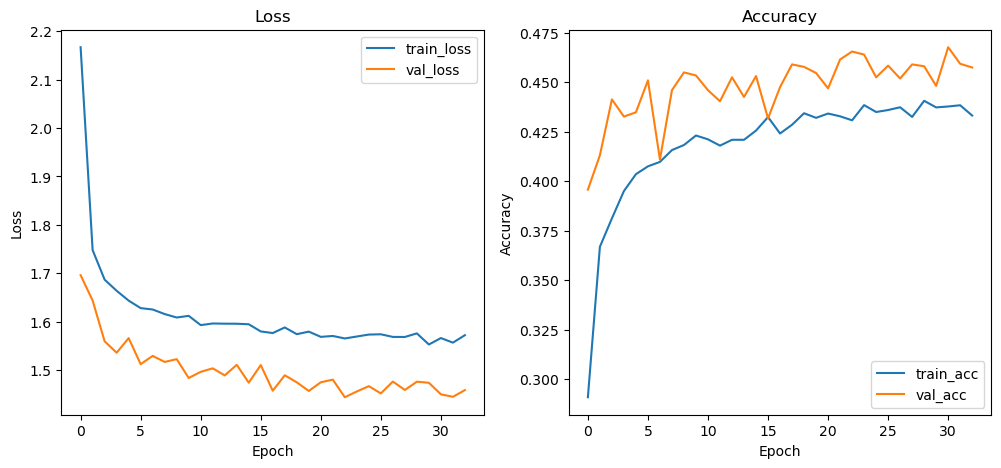

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
model = load_model("mp_rgb_model.h5")

In [ ]:
def load_keypoints_dataset(base_dir):
    X, y = [], []
    for class_name in sorted(os.listdir(base_dir)):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file in os.listdir(class_path):
            if not file.endswith(".npy"):
                continue
            keypoints = np.load(os.path.join(class_path, file))
            X.append(keypoints)
            y.append(class_name)
    return np.array(X), np.array(y)

# load test data
X_test, y_test = load_keypoints_dataset("keypoints_dataset/test")

# Encode labels using  same LabelEncoder as training
# `le` is label encoder fitted on training labels
y_test_enc = le.transform(y_test) 
y_test_cat = to_categorical(y_test_enc)  # one-hot

# scaler is the StandardScaler fitted on training data
# scalar.transform() standardizes test features using training mean and std
X_test = scaler.transform(X_test)

print("X_test shape:", X_test.shape)
print("y_test_cat shape:", y_test_cat.shape)

In [ ]:
# Predict probabilities
yhat_probs = model.predict(X_test)  # shape (num_samples, 9)

# Convert probabilities to predicted class indices
yhat = np.argmax(yhat_probs, axis=1)

# True class indices
ytrue = np.argmax(y_test_cat, axis=1)  # one-hot

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(ytrue, yhat)
print(f"Test Accuracy: {acc*100:.2f}%")